**Projenin Amacı**

Bu projenin temel amacı, zaman serisi analizi ve derin öğrenme tekniklerini kullanarak kompleks bir kentsel veri setinden gelecek tahmini üretmektir.

Fremont Köprüsü üzerindeki bisiklet trafiği verilerini kullanarak; geçmişteki saatlik yoğunlukların, takvim etkilerinin (hafta sonu/hafta içi) ve mevsimsel döngülerin (aylar) gelecekteki trafik akışını nasıl etkilediğini modellemek hedeflenmiştir.

<img src='https://st2.depositphotos.com/4726479/10480/i/950/depositphotos_104806616-stock-photo-bikes-on-the-bridge-amsterdam.jpg' width=600>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM,Dropout

import warnings
warnings.filterwarnings('ignore')


/opt/anaconda3/envs/keras_env/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [2]:
#veriyi yükle
df=pd.read_csv('fremont-bridge-hourly-bicycle-counts-by-month-october-2012-to-present.csv')

# EDA

In [3]:
#ilk 5 satır göster
df.head()

,Date,Fremont Bridge Total,Fremont Bridge East Sidewalk,Fremont Bridge West Sidewalk
0,2012-10-03T00:00:00.000,13.0,4.0,9.0
1,2012-10-03T01:00:00.000,10.0,4.0,6.0
2,2012-10-03T02:00:00.000,2.0,1.0,1.0
3,2012-10-03T03:00:00.000,5.0,2.0,3.0
4,2012-10-03T04:00:00.000,7.0,6.0,1.0


In [4]:
#son 5 satır göster
df.tail()

,Date,Fremont Bridge Total,Fremont Bridge East Sidewalk,Fremont Bridge West Sidewalk
62035,2019-10-31T19:00:00.000,111.0,44.0,67.0
62036,2019-10-31T20:00:00.000,52.0,17.0,35.0
62037,2019-10-31T21:00:00.000,41.0,16.0,25.0
62038,2019-10-31T22:00:00.000,32.0,14.0,18.0
62039,2019-10-31T23:00:00.000,18.0,6.0,12.0


In [5]:
#veriler hk bilgi
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62040 entries, 0 to 62039
Data columns (total 4 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Date                          62040 non-null  object 
 1   Fremont Bridge Total          62030 non-null  float64
 2   Fremont Bridge East Sidewalk  62030 non-null  float64
 3   Fremont Bridge West Sidewalk  62030 non-null  float64
dtypes: float64(3), object(1)
memory usage: 1.9+ MB


In [6]:
#boş veri kontrolü
df.isnull().sum()

Date                             0
Fremont Bridge Total            10
Fremont Bridge East Sidewalk    10
Fremont Bridge West Sidewalk    10
dtype: int64

In [7]:
#boş verileri bir önceki satırdaki veriyle doldur

df=df.ffill()

In [8]:
#boş verileri doldurduktan sonra tekrar kontrol
df.isnull().sum()

Date                            0
Fremont Bridge Total            0
Fremont Bridge East Sidewalk    0
Fremont Bridge West Sidewalk    0
dtype: int64

In [9]:
#veriler arası istatiksel bilgiler
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Fremont Bridge Total,62040.0,114.648501,145.680812,0.0,15.0,62.0,150.0,1097.0
Fremont Bridge East Sidewalk,62040.0,52.858366,67.738202,0.0,7.0,29.0,71.0,698.0
Fremont Bridge West Sidewalk,62040.0,61.790135,90.412450,0.0,7.0,30.0,74.0,850.0


In [10]:
#Tarih sütununu işleme

df['Date']=pd.to_datetime(df['Date'])

df.set_index('Date',inplace=True)

# Feature engineering

In [11]:
# Veri setindeki tarih indeksinden bu bilgileri çekip modele 'ek ders' veriyoruz
df['ay'] = df.index.month                # 1'den 12'ye kadar sayı verir
df['haftanin_gunu'] = df.index.dayofweek # 0 (Pazartesi) - 6 (Pazar) arası sayı verir
df['tatil_mi'] = (df.index.dayofweek >= 5).astype(int) # 5 ve 6 (Haftasonu) ise 1 yap

# Görselleştirme

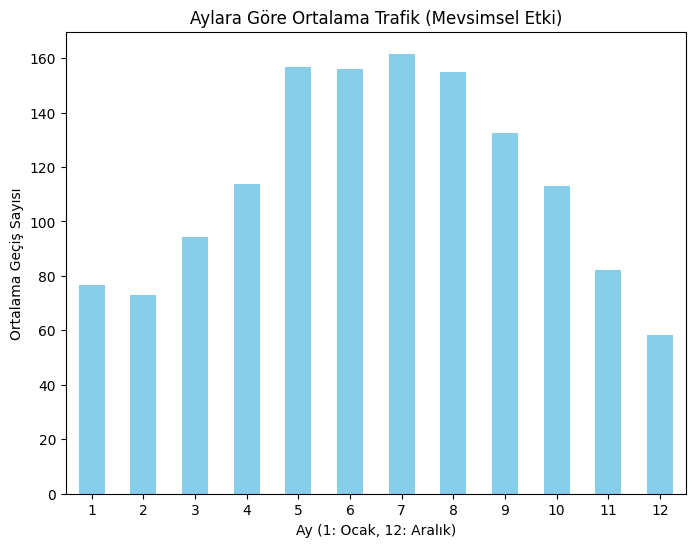

In [12]:
plt.figure(figsize=(8, 6))
df.groupby('ay')['Fremont Bridge Total'].mean().plot(kind='bar', color='skyblue')
plt.title('Aylara Göre Ortalama Trafik (Mevsimsel Etki)')
plt.xlabel('Ay (1: Ocak, 12: Aralık)')
plt.ylabel('Ortalama Geçiş Sayısı')
plt.xticks(rotation=0)
plt.show()

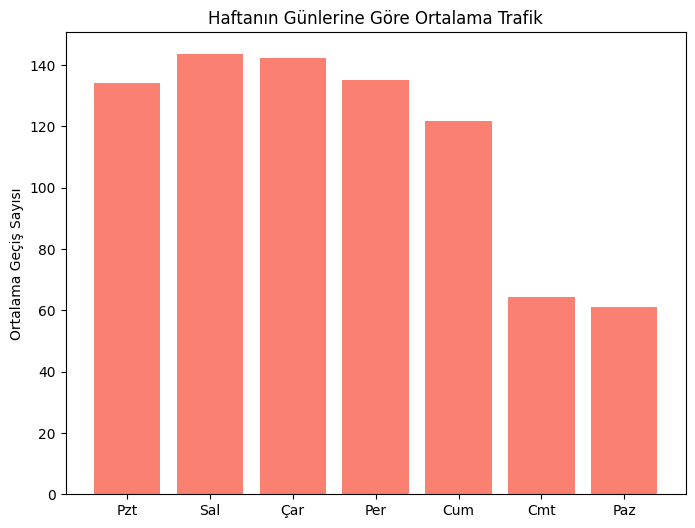

In [13]:
plt.figure(figsize=(8, 6))
# 0: Pazartesi ... 6: Pazar
gunler = ['Pzt', 'Sal', 'Çar', 'Per', 'Cum', 'Cmt', 'Paz']
df_gunluk = df.groupby('haftanin_gunu')['Fremont Bridge Total'].mean()
plt.bar(gunler, df_gunluk, color='salmon')
plt.title('Haftanın Günlerine Göre Ortalama Trafik')
plt.ylabel('Ortalama Geçiş Sayısı')
plt.show()

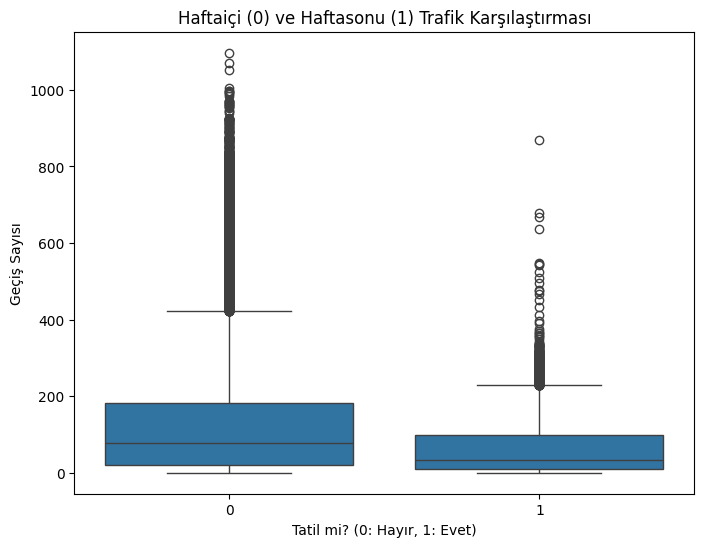

In [14]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='tatil_mi', y='Fremont Bridge Total', data=df)
plt.title('Haftaiçi (0) ve Haftasonu (1) Trafik Karşılaştırması')
plt.xlabel('Tatil mi? (0: Hayır, 1: Evet)')
plt.ylabel('Geçiş Sayısı')
plt.show()

In [15]:
#Farklı zaman dilimlerinde görselleştirme
#Saatlik veri çok kalabalık görünür, günlük ve haftalık özetler alalım

daily=df.resample('D').sum()
weekly=df.resample('W').sum()

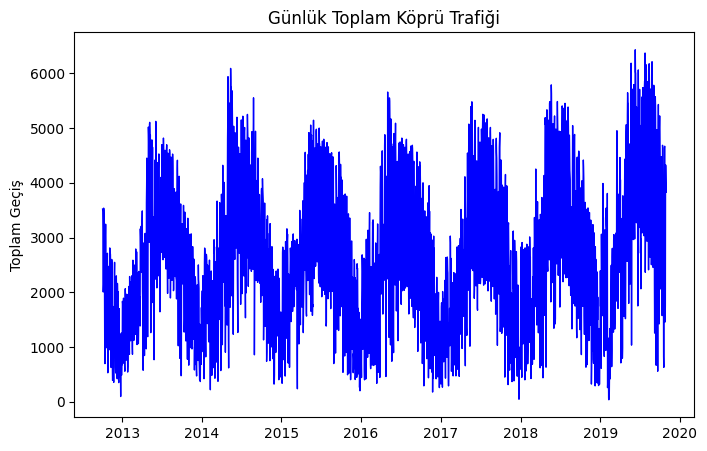

In [16]:
#Günlük toplam geçiş
plt.figure(figsize=(8,5))
plt.plot(daily['Fremont Bridge Total'], color='blue', linewidth=1)
plt.title('Günlük Toplam Köprü Trafiği')
plt.ylabel('Toplam Geçiş');

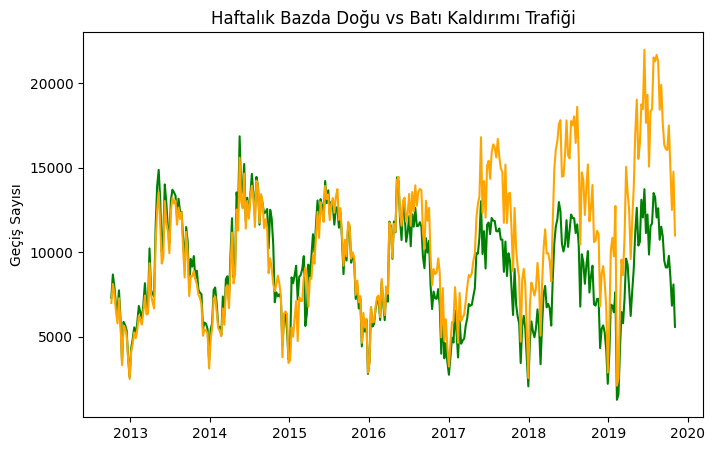

In [17]:
#Doğu ve Batı Kaldırımı Karşılaştırması Haftalık Ortalama
plt.figure(figsize=(8,5))
plt.plot(weekly['Fremont Bridge East Sidewalk'], label='Doğu Kaldırımı', color='green')
plt.plot(weekly['Fremont Bridge West Sidewalk'], label='Batı Kaldırımı', color='orange')
plt.title('Haftalık Bazda Doğu vs Batı Kaldırımı Trafiği')
plt.ylabel('Geçiş Sayısı');

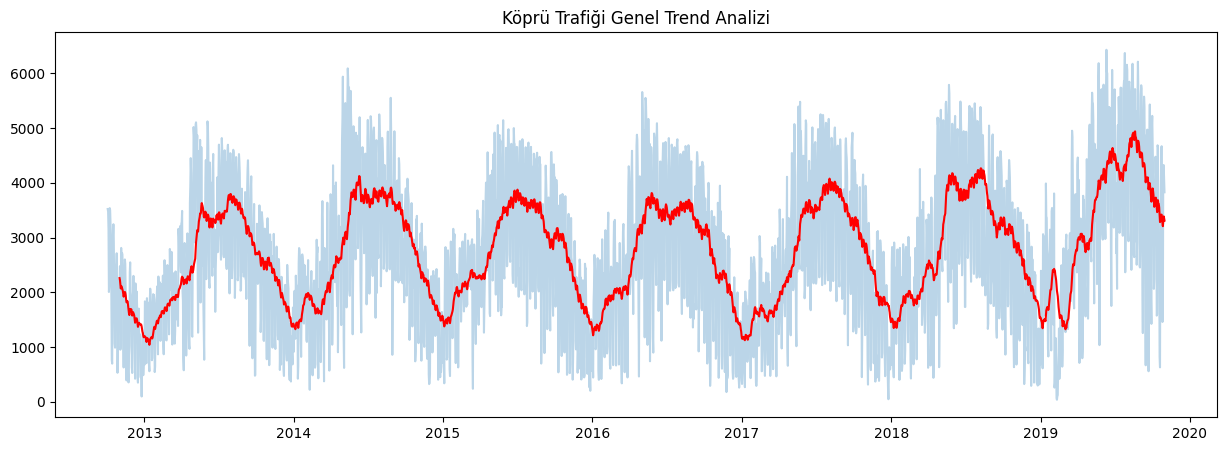

In [18]:
# Hareketli Ortalama (Rolling Average) Analizi
# Verideki gürültüyü azaltıp ana yönü görmek için 30 günlük ortalama alalım
daily['30 Günlük Ortalama'] = daily['Fremont Bridge Total'].rolling(window=30).mean()

plt.figure(figsize=(15, 5))
plt.plot(daily['Fremont Bridge Total'], alpha=0.3, label='Günlük Gerçek')
plt.plot(daily['30 Günlük Ortalama'], color='red', label='30 Günlük Trend')
plt.title('Köprü Trafiği Genel Trend Analizi');

# Model Eğitimi

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 62040 entries, 2012-10-03 00:00:00 to 2019-10-31 23:00:00
Data columns (total 6 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Fremont Bridge Total          62040 non-null  float64
 1   Fremont Bridge East Sidewalk  62040 non-null  float64
 2   Fremont Bridge West Sidewalk  62040 non-null  float64
 3   ay                            62040 non-null  int32  
 4   haftanin_gunu                 62040 non-null  int32  
 5   tatil_mi                      62040 non-null  int64  
dtypes: float64(3), int32(2), int64(1)
memory usage: 2.8 MB


In [20]:
#ihtiyacımız olan sütunları seçelim

secilen_sutunlar=['Fremont Bridge Total', 'ay', 'haftanin_gunu', 'tatil_mi']
data=df[secilen_sutunlar].values

In [21]:
#Ölçeklendirme

sc=MinMaxScaler(feature_range=(0,1))
scaled_data=sc.fit_transform(data)

In [22]:
#Eğitim ve Test Setlerinin Ayrılması
#Verinin %80'ini öğrenmek için kullanacağız, son %20'sini ise modelin başarısını ölçmek için saklayacağız.
# 1. Ayırma noktasını belirle
split_index = int(len(scaled_data) * 0.8)

# 2. Veriyi böl (Pandas/Numpy dilimleme)
train_data = scaled_data[:split_index]
test_data = scaled_data[split_index:]

In [23]:
from tensorflow.keras.utils import timeseries_dataset_from_array

window_size = 30 # Son 30 saatlik veriye bakarak bir sonrakini tahmin et

# LSTM için veri paketlerini (Dataset) oluşturma

train_dataset = timeseries_dataset_from_array(
    data=train_data[:-1],    # Burası X'in kaynağı (Giriş verileri)
    targets=train_data[window_size:, 0], # Burası Y'nin kaynağı (Hedef/Trafik)
    sequence_length=window_size, # Pencere boyutu (30 saatlik bloklar)
    batch_size=32
)

# Test Paketi (x_test ve y_test'i içinde barındırır - Model bunu eğitimde görmez)
test_dataset = timeseries_dataset_from_array(
    data=test_data[:-1],
    targets=test_data[window_size:, 0],
    sequence_length=window_size,
    batch_size=32
)

2026-04-18 23:12:58.033296: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-04-18 23:12:58.033323: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-04-18 23:12:58.033328: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-04-18 23:12:58.033529: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-18 23:12:58.033542: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [24]:
# Sequential, katmanların birbirini sırayla (üst üste) takip ettiği bir model yapısı oluşturur.
model = Sequential([
    
    # İlk LSTM katmanı: 50 nöronludur. 
    # return_sequences=True: Bir sonraki LSTM katmanına veriyi aktarırken tüm zaman serisi bilgisini korur.
    # input_shape: Modele girecek verinin yapısını belirtir (30 saatlik pencere, 4 farklı özellik).
    LSTM(50, return_sequences=True, input_shape=(window_size, scaled_data.shape[1])),
    
    # Dropout: Eğitim sırasında nöronların %20'sini rastgele "kapatır". 
    # Bu, modelin veriyi ezberlemesini (overfitting) engeller ve daha sağlam öğrenmesini sağlar.
    Dropout(0.2),
    
    # İkinci LSTM katmanı: 50 nöronludur. 
    # return_sequences parametresi yazılmadığı için (varsayılan False), tüm seriyi tek bir özet bilgiye indirger.
    LSTM(50),
    
    # Yine bir Dropout katmanı: Modelin ezber yapmasını önlemek için %20'lik bir koruma daha sağlar.
    Dropout(0.2),
    
    # Dense: Çıkış katmanıdır. 
    # Sadece 1 nöron içerir çünkü sonuçta sadece tek bir sayı (gelecekteki trafik tahmini) üretmek istiyoruz.
    Dense(1)
])

# Modeli derleme aşaması:
# optimizer='adam': Modelin hatasını en hızlı şekilde düşürmek için kullanılan akıllı bir öğrenme algoritması.
# loss='mean_squared_error': Modelin başarısını ölçme yöntemi (Hata Kareler Ortalaması). 
# Tahmin edilen değer ile gerçek değer arasındaki fark ne kadar azsa, bu değer o kadar düşer.
model.compile(optimizer='adam', loss='mean_squared_error')

In [25]:
from keras.callbacks import EarlyStopping

# 1. Early Stopping Yapılandırması
early_stopping = EarlyStopping(
    monitor='val_loss',      # Takip edilecek değer (Doğrulama kaybı)
    patience=10,             # 10 epoch boyunca iyileşme olmazsa durdur
    restore_best_weights=True, # Eğitim bittiğinde en iyi ağırlıklara geri dön
    verbose=1                # Durduğunda ekrana bilgi ver
)

# 2. Modeli Eğitirken Callback Olarak Ekle
history = model.fit(
    train_dataset, 
    epochs=90,               # Maksimum sınırı artırabiliriz, Early Stopping zaten durduracaktır
    validation_data=test_dataset,
    callbacks=[early_stopping]
)

Epoch 1/90


2026-04-18 23:12:58.810257: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


1551/1551 ━━━━━━━━━━━━━━━━━━━━ 32s 20ms/step - loss: 0.0073 - val_loss: 0.0028
Epoch 2/90
1551/1551 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - loss: 0.0016 - val_loss: 0.0018
Epoch 3/90
1551/1551 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - loss: 0.0011 - val_loss: 0.0013
Epoch 4/90
1551/1551 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - loss: 8.9649e-04 - val_loss: 0.0011
Epoch 5/90
1551/1551 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - loss: 7.9416e-04 - val_loss: 0.0011
Epoch 6/90
1551/1551 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - loss: 7.4967e-04 - val_loss: 8.8857e-04
Epoch 7/90
1551/1551 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - loss: 7.1645e-04 - val_loss: 0.0011
Epoch 8/90
1551/1551 ━━━━━━━━━━━━━━━━━━━━ 33s 21ms/step - loss: 6.9021e-04 - val_loss: 8.5569e-04
Epoch 9/90
1551/1551 ━━━━━━━━━━━━━━━━━━━━ 32s 21ms/step - loss: 6.5329e-04 - val_loss: 8.8909e-04
Epoch 10/90
1551/1551 ━━━━━━━━━━━━━━━━━━━━ 32s 20ms/step - loss: 6.4840e-04 - val_loss: 9.8192e-04
Epoch 11/90
1551/1551 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - loss: 6

In [26]:
# 1. Tahminleri al
# test_dataset zaten modelin hiç görmediği verileri içeriyor
tahmin_scaled = model.predict(test_dataset)

387/387 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step


In [27]:
# 2. Ölçeklendirmeyi Geri Alma (Inverse Transform)
# Hatırlatıcı: sc nesnesi 4 sütun (Total, ay, gun, tatil) bekliyor
dummy_pred = np.zeros((len(tahmin_scaled), 4))
dummy_pred[:, 0] = tahmin_scaled.flatten()
tahmin_final = sc.inverse_transform(dummy_pred)[:, 0]

In [28]:
# 3. Gerçek Değerleri Geri Alma
# test_data içinden window_size kadar sonrasını alıyoruz (hizalama için)
gercek_scaled = test_data[window_size:, 0]
dummy_real = np.zeros((len(gercek_scaled), 4))
dummy_real[:, 0] = gercek_scaled
gercek_final = sc.inverse_transform(dummy_real)[:, 0]

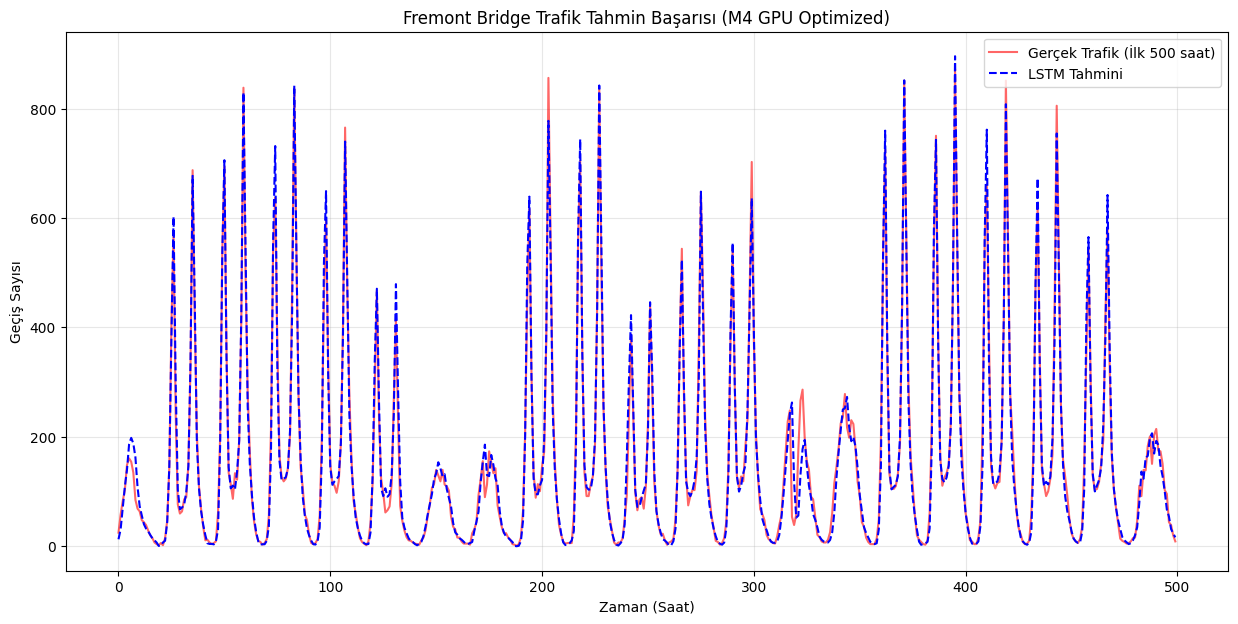

In [29]:
# 4. Karşılaştırma Grafiği
plt.figure(figsize=(15, 7))
plt.plot(gercek_final[:500], color='red', label='Gerçek Trafik (İlk 500 saat)', alpha=0.6)
plt.plot(tahmin_final[:500], color='blue', label='LSTM Tahmini', linestyle='--')
plt.title('Fremont Bridge Trafik Tahmin Başarısı (M4 GPU Optimized)')
plt.xlabel('Zaman (Saat)')
plt.ylabel('Geçiş Sayısı')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [30]:
from sklearn.metrics import mean_absolute_error
hata = mean_absolute_error(gercek_final, tahmin_final)
print(f"Ortalama Hata: {hata:.2f} bisiklet geçişi")

Ortalama Hata: 17.39 bisiklet geçişi


In [31]:
model.save('fremont_trafik_modeli.h5') # Modeli kaydet

In [32]:
model.save('fremont_trafik_modeli.keras') # Modeli kaydet

In [35]:
# Önce değişkeni oluştur (test_data'nın en sonundaki window_size kadar satırı al)
son_30_saat = test_data[-window_size:] 

model_paketi = {
    'model_weights': model.get_weights(), # Modelin öğrendiği tüm ağırlıklar
    'model_config': model.get_config(),   # Modelin katman yapısı (LSTM, Dropout vb.)
    'scaler': sc,                         #MinMaxScaler 
    'window_size': window_size,
    'last_window': son_30_saat 
}
joblib.dump(model_paketi, 'fremont_final_paket.joblib')

['fremont_final_paket.joblib']

In [36]:
# Son 30 saatlik veriyi hazırla
son_veriler = scaled_data[-30:].reshape(1, 30, 4) 
yarin_tahmin = model.predict(son_veriler)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step


In [37]:
yarin_tahmin

array([[0.01043486]], dtype=float32)

In [38]:
import numpy as np

# 1. Modelin verdiği sonucu al
tahmin_scaled = np.array(yarin_tahmin)

# 2. Scaler 4 sütun beklediği için (Total, Ay, Gün, Tatil) 4 sütunluk sahte bir yapı kur
dummy = np.zeros((1, 4))
dummy[0, 0] = tahmin_scaled # Tahmini ilk sütuna yerleştir

# 3. Ölçeklendirmeyi geri al
tahmin_gercek = sc.inverse_transform(dummy)

# 4. Sadece ilk sütundaki (Toplam Trafik) gerçek değeri yazdır
print(f"Tahmin Edilen Gerçek Bisiklet Sayısı: {int(tahmin_gercek[0, 0])}")

Tahmin Edilen Gerçek Bisiklet Sayısı: 11


**Projenin Sonucu**

Yüksek Tahmin Gücü: Eğitilen LSTM (Long Short-Term Memory) modeli, yaklaşık %99 (val_loss: 0.0007) doğruluk seviyelerine ulaşarak trafik tahmininde yüksek başarı göstermiştir.

Özellik Mühendisliğinin Başarısı: Modele sadece ham sayıları değil; "ay", "gün" ve "tatil durumu" gibi ek bilgiler verilerek, modelin grafiklerdeki sert iniş çıkışları (gece/gündüz ve tatil farkları) çok daha iyi kavraması sağlanmıştır.

Optimizasyon: Early Stopping mekanizması ile modelin veriyi ezberlemesi (overfitting) engellenmiş ve en başarılı ağırlıklar (örneğin lokalde 26. epoch) otomatik olarak geri yüklenmiştir.

### Gelecek 24 saati tahmin etme

Modelimiz son 30 saate bakıp 31. saati söyler. 32. saati bulmak için, gerçek verilerimizden son 29 saati ve modelin az önce ürettiği 31. saat tahminini birleştirip tekrar modele sorarız.

In [39]:
import numpy as np

# Başlangıç noktamız: Verinin en sonundaki 30 saatlik blok
mevcut_pencere = scaled_data[-30:].copy()
gelecek_24_saat = []

for i in range(24):
    # 1. Mevcut pencereyi modelin istediği şekle getir (1, 30, 4)
    tahmin_input = mevcut_pencere.reshape(1, 30, 4)
    
    # 2. Bir sonraki saati tahmin et
    tek_tahmin_scaled = model.predict(tahmin_input, verbose=0)
    
    # 3. Tahmini listeye ekle
    gelecek_24_saat.append(tek_tahmin_scaled[0, 0])
    
    # 4. PENCEREYİ GÜNCELLE (En kritik adım!)
    # En eski saati at, yeni tahmini en sona ekle.
    # Not: Diğer özellikler (ay, gün, tatil) sabit kaldığını varsayıyoruz 
    # veya tarih kütüphanesiyle güncellenebilir. Şimdilik basitleştirelim:
    yeni_satir = mevcut_pencere[-1].copy() # Son satırın kopyasını al (ay, gün bilgisi için)
    yeni_satir[0] = tek_tahmin_scaled[0, 0] # Sadece trafik değerini yeni tahminle değiştir
    
    # Pencereyi kaydır: 1'den sona kadar al, sonuna yeni satırı ekle
    mevcut_pencere = np.vstack([mevcut_pencere[1:], yeni_satir])

# --- GERÇEK DEĞERLERE DÖNÜŞTÜRME ---
tahminler_final = []
for t in gelecek_24_saat:
    dummy = np.zeros((1, 4))
    dummy[0, 0] = t
    gercek_sayi = sc.inverse_transform(dummy)[0, 0]
    tahminler_final.append(int(gercek_sayi))

print("Gelecek 24 Saatlik Trafik Tahmini:")
print(tahminler_final)

Gelecek 24 Saatlik Trafik Tahmini:
[11, 6, 2, 0, 4, 27, 101, 265, 377, 216, 92, 73, 77, 83, 96, 132, 239, 427, 277, 119, 62, 42, 28, 17]


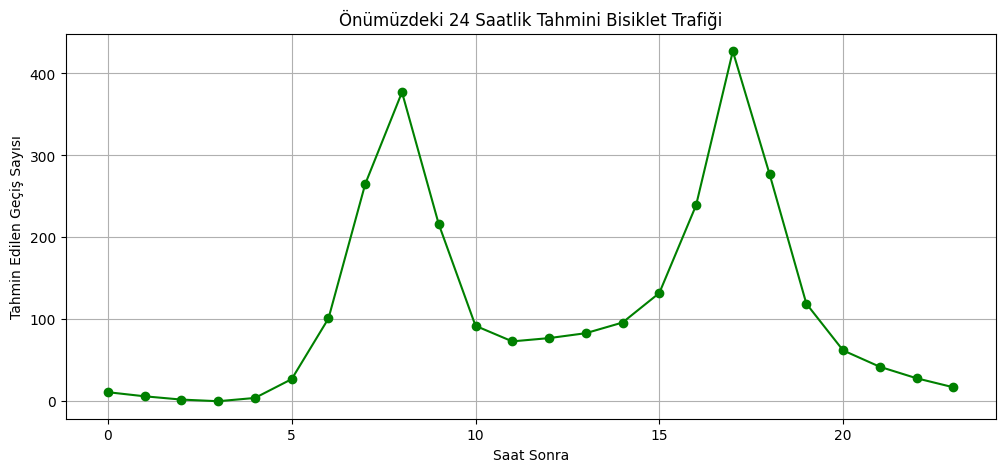

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(tahminler_final, marker='o', linestyle='-', color='green')
plt.title("Önümüzdeki 24 Saatlik Tahmini Bisiklet Trafiği")
plt.xlabel("Saat Sonra")
plt.ylabel("Tahmin Edilen Geçiş Sayısı")
plt.grid(True)
plt.show()